# Preprocessing Sanity Check

Verifies that the preprocessing code is working correctly by loading the saved splits, inspecting batch shapes, and visualizing sample images.

## 1. Imports and Setup

Add the project root to `sys.path` so we can import from `src/`, then bring in the preprocessing module and matplotlib.

In [ ]:
import sys
from pathlib import Path

#Regardless of where this notebook is run from make sure that src/ is importable
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import torch

from src.preprocessing import CLASS_TO_IDX, IMAGENET_MEAN, IMAGENET_STD, get_dataloaders

## 2. Load DataLoaders

Build DataLoaders for all three splits using the saved CSVs in `data/splits/`.

In [2]:
loaders = get_dataloaders(batch_size=32)

train_loader = loaders["train"]
val_loader   = loaders["val"]
test_loader  = loaders["test"]

## 3. Split Sizes

Print the number of samples and batches for each split to confirm the data was loaded as expected.

In [3]:
for name, loader in loaders.items():
    n_samples = len(loader.dataset)
    n_batches = len(loader)
    print(f"{name:>5}  —  {n_samples:>5} samples  |  {n_batches:>3} batches")

train  —   4480 samples  |  140 batches
  val  —   1120 samples  |   35 batches
 test  —   1600 samples  |   50 batches


## 4. Inspect One Batch

Pull the first batch from the train loader and print its shape and the raw label tensor.

In [4]:
images, labels = next(iter(train_loader))

print("Batch image tensor shape:", tuple(images.shape))  # (B, C, H, W)
print("Batch label tensor:      ", labels)

Batch image tensor shape: (32, 3, 224, 224)
Batch label tensor:       tensor([2, 3, 3, 1, 1, 2, 0, 1, 1, 3, 1, 3, 3, 2, 0, 0, 1, 1, 1, 0, 3, 3, 2, 2,
        1, 2, 2, 2, 2, 2, 3, 2])


## 5. Visualize Sample Images

Displays a 4 x 4 grid of images from the batch. The images are denormalized (ImageNet mean/std reversed) before plotting so they look natural.

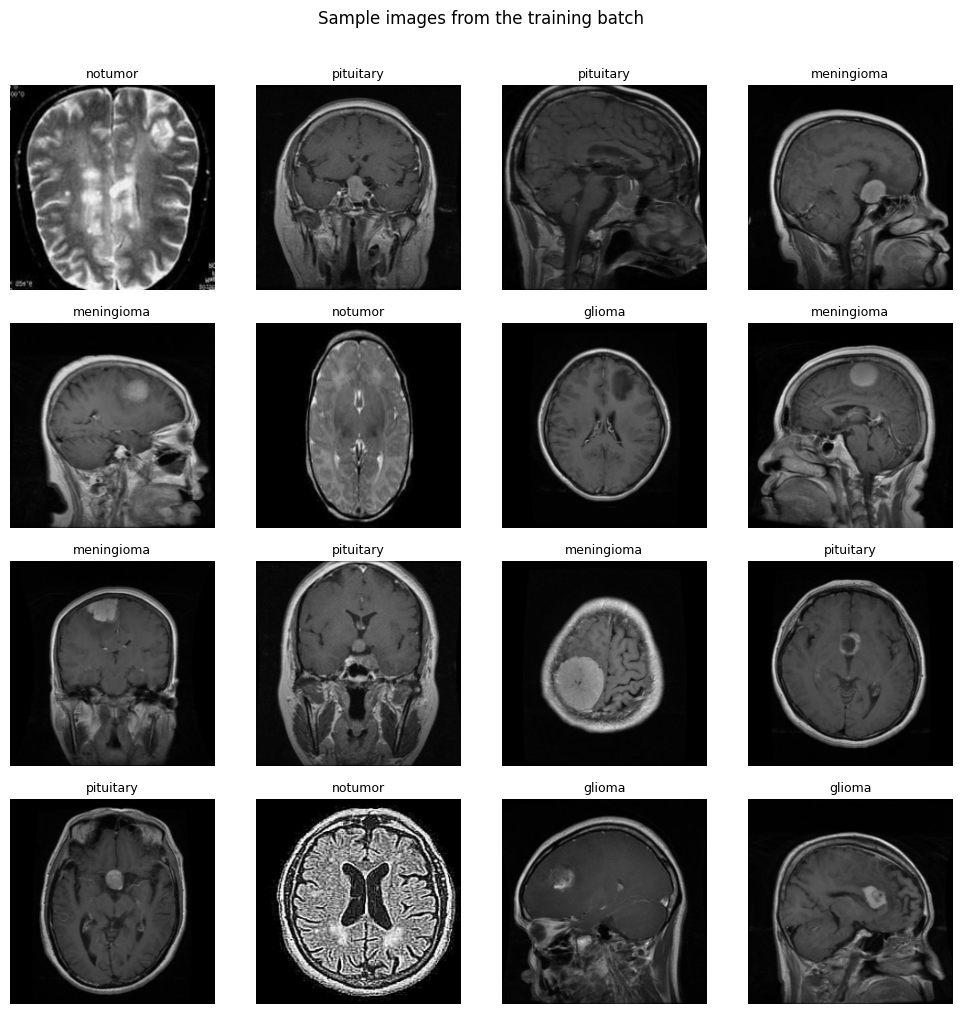

In [ ]:
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denormalize(tensor):
    """
    Reverse ImageNet normalization
    """
    return (tensor * std + mean).clamp(0, 1)

n_cols, n_rows = 4, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(IDX_TO_CLASS[labels[i].item()], fontsize=9)
    ax.axis("off")

plt.suptitle("Sample images from the training batch", y=1.01)
plt.tight_layout()
plt.show()

## 6. Class-to-Index Mapping

Print the `CLASS_TO_IDX` mapping to confirm the label indices match the dataset.

In [6]:
print("Class -> Index mapping:")
for cls, idx in CLASS_TO_IDX.items():
    print(f"  {idx}  {cls}")

Class -> Index mapping:
  0  glioma
  1  meningioma
  2  notumor
  3  pituitary
